# AirBnB Listing Analysis

## Objective A: Exploring the data to understand its structure and correct quality issues

- Importing Pandas
- Reading the Listings.csv file
- Casting the 'host_since' column as a datetime format
- Filtering the table down to rows where the city is **Paris** and keeping only the columns `host_since`, `neighbourhood`, `city`, `accomodates`, and `price` in the table.
- Performing data quality assurance by
    - Checking for missing values
    - Calculating the minimum, maximum, and average for each numeric field.


In [124]:
import pandas as pd
listings = pd.read_csv('Listings.csv', encoding="ISO-8859-1", low_memory=False)

In [125]:
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [126]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [127]:
listings['host_since'] = pd.to_datetime(listings['host_since'])
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [128]:
paris_listings = (
    listings
        .query("city == 'Paris'")
        .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)
paris_listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [129]:
paris_listings.isna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [130]:
paris_listings.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [131]:
paris_listings.query('accommodates == 0').count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

In [132]:
paris_listings.query('price == 0 and accommodates ==0').count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

## Objective B: Preparing for visualisation
- Creating a table named **paris_listings_neighbourhood** that groups Paris listings by `neighbourhood` and calculates the mean price for each neighbourhood, sorted from highest to lowest average price.

- Creating a table named **paris_listing_accommodates**. The table should be filtered to the most expensive neighbourhood in Paris, grouped by the `accommodates` column, and contain the mean price for each value of `accommodates`, sorted from lowest to highest average price.

- Creating a table named **paris_listings_over_time**, grouped by the year of the `host_since` column. Calculate:
  - The count of rows representing the total number of new hosts
  - The average price for each year


In [133]:
paris_listings_neighbourhood = (
    paris_listings
        .groupby('neighbourhood')
        .agg({'price':'mean'})
        .sort_values('price', ascending=False)
)

paris_listings_neighbourhood.head()

,price
neighbourhood,
Elysee,210.536765
Louvre,175.379972
Passy,161.144635
Palais-Bourbon,156.856578
Luxembourg,155.638639


In [134]:
paris_listings_accommodates = (
    paris_listings
        .query("neighbourhood == 'Elysee'")
        .groupby('accommodates')
        .agg({'price':'mean'})
        .sort_values('price')
)

paris_listings_accommodates.head()

,price
accommodates,
0,0.000000
1,79.522222
3,152.828767
2,155.103352
4,212.096070


In [135]:
paris_listings_over_time = (
    paris_listings
        .set_index('host_since')
        .resample('YE')
        .agg({'neighbourhood':'count', 
            'price':'mean'})
    )

paris_listings_over_time.head()

,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


## Objective C: Visualising the data
- Creating a horizontal bar chart of the average price by `neighbourhood`in Paris. The title is added and appropriate axes labels

- Creating a horizontal bar chart of the average price by `accommodates`in Paris' most expensive neighbourhood. The title is added and appropriate axes labels are too.

- Creating dual axes charts. One chart for the count of new hosts over time, and the other is for the average price (€) over time. The y-axis limit is set to 0. The title is added as well as the appropriate axes labels.


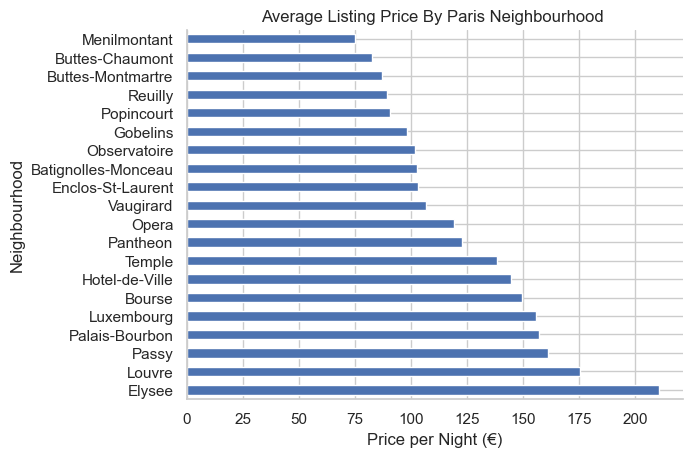

In [136]:
import seaborn as sb

(paris_listings_neighbourhood
 .plot
 .barh(
    title="Average Listing Price By Paris Neighbourhood ",
    xlabel="Price per Night (€)",
    ylabel="Neighbourhood",
    legend=None
    )
)

sb.despine()

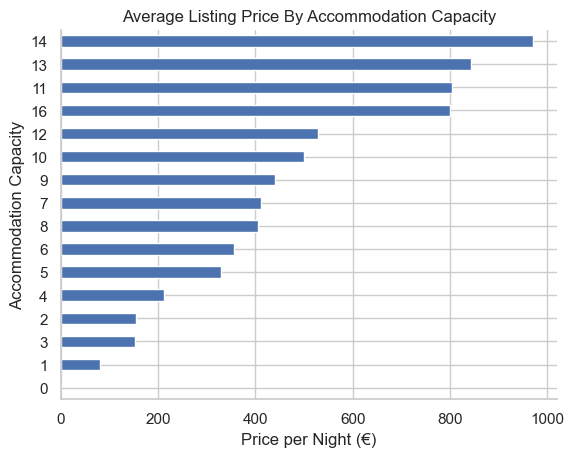

In [137]:
import seaborn as sb

(paris_listings_accommodates
 .plot
 .barh(
    title="Average Listing Price By Accommodation Capacity",
    xlabel="Price per Night (€)",
    ylabel="Accommodation Capacity",
    legend=None
    )
)

sb.despine()

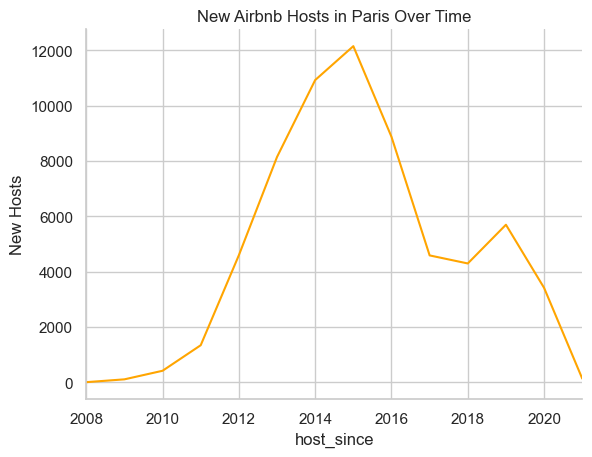

In [138]:
import seaborn as sb

(paris_listings_over_time['neighbourhood']
 .plot(
    ylabel='New Hosts',
    title='New Airbnb Hosts in Paris Over Time',
    c = 'orange',
    legend=None
 )
)

sb.despine()

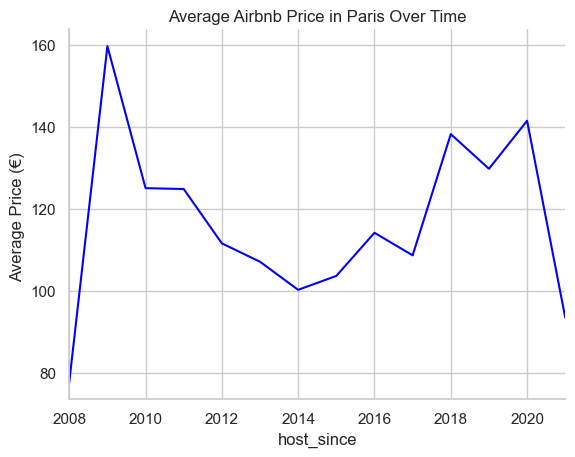

In [139]:
import seaborn as sb

(paris_listings_over_time['price']
 .plot(
    ylabel='Average Price (€) ',
    title='Average Airbnb Price in Paris Over Time',
    c = 'blue',
    legend=None
 )
)

sb.despine()

Text(0.5, 1.0, 'Airbnb Listings Growth Peaks in 2015')

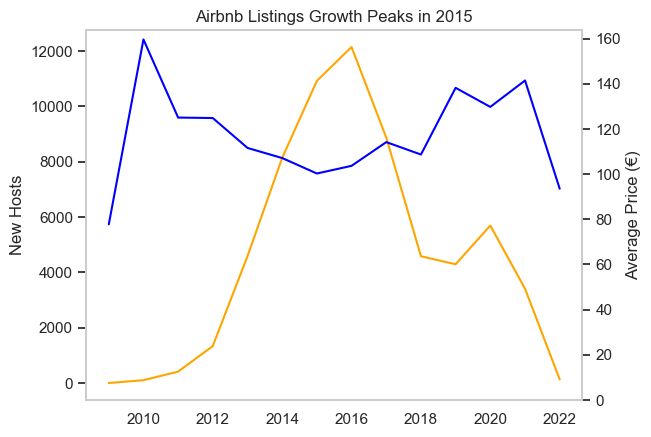

In [140]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(
    paris_listings_over_time.index,
    paris_listings_over_time['neighbourhood'],
    label = 'New Host',
    c = 'orange'

)
ax.set_ylabel("New Hosts")
ax.grid(False) 

ax2 = ax.twinx()
ax2.plot(
    paris_listings_over_time.index,
    paris_listings_over_time['price'],
    label = 'Average Price',
    c = 'blue'

)
ax2.set_ylim(0)
ax2.set_ylabel("Average Price (€)")
ax2.grid(False) 

ax.set_title('Airbnb Listings Growth Peaks in 2015')